In [164]:
import rasterio
from pathlib import Path

TILE_ID = "tile_-379_2250_p1"  # fill in actual tile_id

tile_dir = Path(f"../data/test_tiles/{TILE_ID}")  # fill in actual tile_id

tif_paths = sorted(tile_dir.glob("*/*.tif"))

print(f"{'file':40s} {'crs':25s} {'shape':12s} {'transform'}")
ref = None
for p in tif_paths:
    with rasterio.open(p) as src:
        info = (src.crs, (src.height, src.width), src.transform)
        rel = p.relative_to(tile_dir)
        print(f"{str(rel):40s} {str(info[0]):25s} {str(info[1]):12s} {info[2]}")
        if ref is None:
            ref = info
        else:
            same_crs = info[0] == ref[0]
            same_shape = info[1] == ref[1]
            same_transform = info[2].almost_equals(ref[2], precision=6)
            if not (same_crs and same_shape and same_transform):
                print(f"  !! MISALIGNED vs {tif_paths[0].relative_to(tile_dir)}: "
                      f"crs={same_crs} shape={same_shape} transform={same_transform}")

file                                     crs                       shape        transform
composites/s1s2_2017.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-970240.00|
| 0.00,-10.00, 5762560.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2018.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-970240.00|
| 0.00,-10.00, 5762560.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2019.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-970240.00|
| 0.00,-10.00, 5762560.00|
| 0.00, 0.00, 1.00|
composites/s1s2_2020.tif                 EPSG:6933                 (256, 256)   | 10.00, 0.00,-970240.00|
| 0.00,-10.00, 5762560.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2017.tif                  EPSG:6933                 (256, 256)   | 10.00, 0.00,-970240.00|
| 0.00,-10.00, 5762560.00|
| 0.00, 0.00, 1.00|
embeddings/aee_2018.tif                  EPSG:6933                 (256, 256)   | 10.00, 0.00,-970240.00|
| 0.00,-10.00, 5762560.00|
| 0.00, 0.00

In [179]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
import rasterio
from matplotlib.colors import Normalize


PERIOD_YEARS = {
    "p1": range(2017, 2021),
    "p2": range(2020, 2025),
}

period = TILE_ID.rsplit("_", 1)[-1]

if period not in PERIOD_YEARS:
    raise ValueError(f"Unknown period '{period}'")

years = list(PERIOD_YEARS[period])


def read(path, bands=None):
    with rasterio.open(path) as src:
        arr = src.read(bands) if bands else src.read()
        return arr, src.bounds, src.transform


def stretch(arr, low=2, high=98):
    """
    Independent percentile stretch for visualisation only.
    """
    out = np.empty_like(arr, dtype="float32")

    for b in range(arr.shape[-1]):
        lo, hi = np.nanpercentile(arr[..., b], [low, high])

        if hi == lo:
            out[..., b] = 0
        else:
            out[..., b] = np.clip(
                (arr[..., b] - lo) / (hi - lo),
                0,
                1,
            )

    return out


# -----------------------
# Static layers
# -----------------------

slope, _, _ = read(
    tile_dir / "static" / "slope.tif",
    bands=[1],
)

protected, _, _ = read(
    tile_dir / "static" / "protected_area.tif",
    bands=[1],
)

# IMPORTANT:
# This is the continuous gain confidence product.
# Do not threshold it here.
gain_conf, _, _ = read(
    tile_dir / "labels" / "gain_confidence.tif",
    bands=[1],
)

gain_conf = gain_conf[0]

# mask only missing pixels
gain_conf_masked = np.ma.masked_where(
    np.isnan(gain_conf),
    gain_conf,
)

# fixed confidence scale (raw exported range is 50-100, not 0-1)
gain_norm = Normalize(
    vmin=50,
    vmax=100,
)


# -----------------------
# Build frames
# -----------------------

frames = []

for year in years:

    composite = tile_dir / "composites" / f"s1s2_{year}.tif"


    # Sentinel-2 RGB
    s2, _, _ = read(
        composite,
        bands=[3, 2, 1],
    )

    rgb = stretch(
        s2.transpose(1, 2, 0)
    )


    # NDVI
    ndvi, _, _ = read(
        composite,
        bands=[8],
    )


    # Sentinel-1
    # bands:
    # 10 = VV
    # 11 = VH
    s1, _, _ = read(
        composite,
        bands=[10, 11],
    )

    vv = s1[0]
    vh = s1[1]

    # RGB visualisation:
    # R = VV
    # G = VH
    # B = VV - VH
    s1_rgb = stretch(
        np.stack(
            [
                vv,
                vh,
                vv - vh,
            ],
            axis=-1,
        )
    )


    # TESSERA
    tess, _, _ = read(
        tile_dir / "embeddings" / f"tessera_{year}.tif",
        bands=[1, 2, 3],
    )

    tess_rgb = stretch(
        tess.transpose(1, 2, 0)
    )


    # AEE
    aee, _, _ = read(
        tile_dir / "embeddings" / f"aee_{year}.tif",
        bands=[1, 2, 3],
    )

    aee_rgb = stretch(
        aee.transpose(1, 2, 0)
    )


    frames.append(
        {
            "year": year,
            "rgb": rgb,
            "ndvi": ndvi[0],
            "s1": s1_rgb,
            "tess": tess_rgb,
            "aee": aee_rgb,
        }
    )


# -----------------------
# Plot
# -----------------------

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8),
)

title = fig.suptitle("")


im_rgb = axes[0,0].imshow(
    frames[0]["rgb"]
)
axes[0,0].set_title(
    "Sentinel-2 RGB"
)


im_ndvi = axes[0,1].imshow(
    frames[0]["ndvi"],
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
)
axes[0,1].set_title(
    "NDVI"
)


im_s1 = axes[0,2].imshow(
    frames[0]["s1"]
)
axes[0,2].set_title(
    "Sentinel-1 VV / VH / VV-VH"
)


im_tess = axes[0,3].imshow(
    frames[0]["tess"]
)
axes[0,3].set_title(
    "TESSERA"
)


im_aee = axes[1,0].imshow(
    frames[0]["aee"]
)
axes[1,0].set_title(
    "AEE"
)


axes[1,1].imshow(
    slope[0],
    cmap="viridis",
    vmin=0,
    vmax=max(np.nanmax(slope), 1e-6),
)
axes[1,1].set_title(
    "Slope"
)


axes[1,2].imshow(
    protected[0],
    cmap="Greens",
    vmin=0,
    vmax=1,
)
axes[1,2].set_title(
    "Protected area"
)


# Gain confidence overlay
overlay_rgb = axes[1,3].imshow(
    frames[0]["rgb"]
)

overlay_gain = axes[1,3].imshow(
    gain_conf_masked,
    cmap="plasma",
    norm=gain_norm,
    alpha=0.75,
)

axes[1,3].set_title(
    "Gain confidence"
)

cbar = fig.colorbar(
    overlay_gain,
    ax=axes[1,3],
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Gain confidence (canopy cover %, year_end)"
)


for ax in axes.flat:
    ax.axis("off")


def update(i):

    f = frames[i]

    title.set_text(
        f"{TILE_ID} — {f['year']}"
    )

    im_rgb.set_data(f["rgb"])
    im_ndvi.set_data(f["ndvi"])
    im_s1.set_data(f["s1"])
    im_tess.set_data(f["tess"])
    im_aee.set_data(f["aee"])

    overlay_rgb.set_data(
        f["rgb"]
    )

    # DO NOT update overlay_gain with a binary mask.
    # The confidence raster is static across years.
    return (
        title,
        im_rgb,
        im_ndvi,
        im_s1,
        im_tess,
        im_aee,
        overlay_rgb,
        overlay_gain,
    )


anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=800,
    blit=False,
)


plt.close(fig)

HTML(anim.to_jshtml())

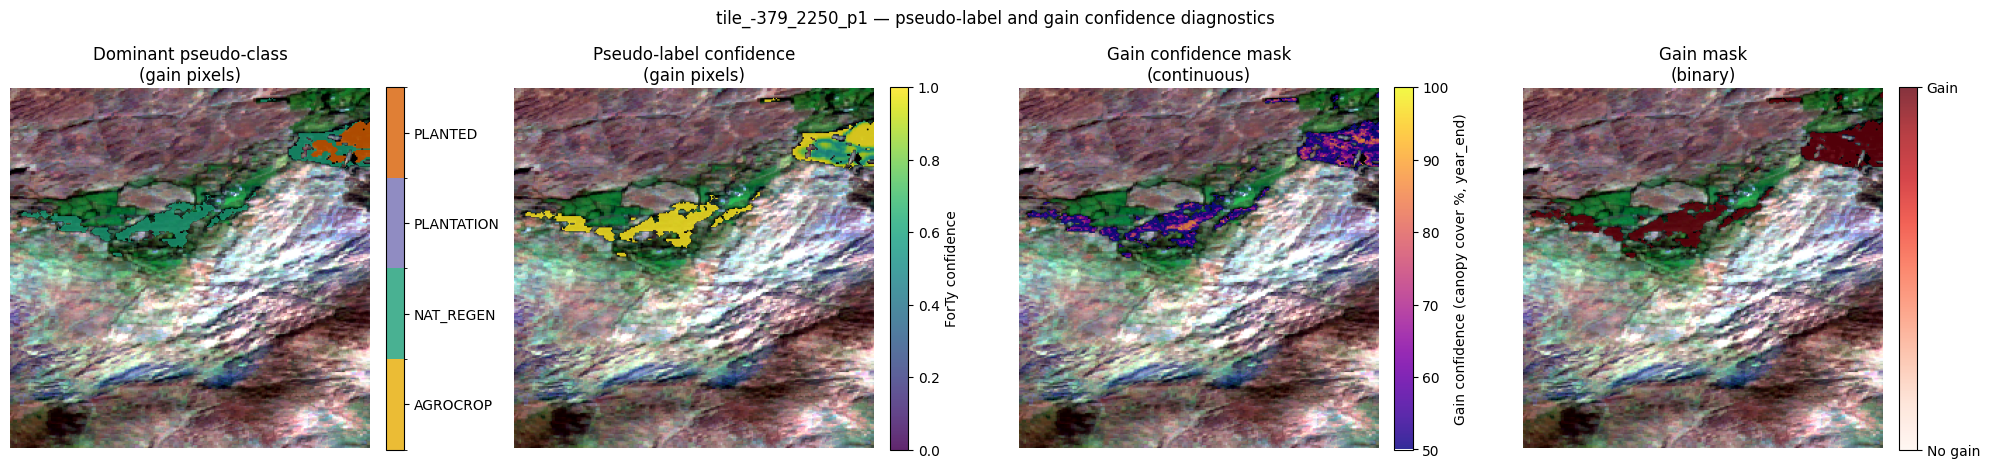

gain pixels: 2861
gain percentage of tile: 4.37%

Dominant class distribution:
  AGROCROP                226 (  7.9%)
  NAT_REGEN              2046 ( 71.5%)
  PLANTED                 589 ( 20.6%)

Gain confidence:
  min:  3.922
  mean: 49.290
  max:  92.941

Pseudo-label confidence:
  mean: 0.920


In [180]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.pyplot as plt
import numpy as np


# -------------------------
# Load labels
# -------------------------

pseudo, _, _ = read(tile_dir / "labels" / "pseudo_labels.tif")

dominant = pseudo[4]      # band 5
confidence = pseudo[5]    # band 6

# Continuous gain confidence
gain_conf, _, _ = read(
    tile_dir / "labels" / "gain_confidence.tif",
    bands=[1],
)
gain_conf = gain_conf[0]

# Binary version derived from confidence (NaN outside coverage, so
# isnan is the correct mask -- gain_conf > 0 happens to work too since
# every valid pixel is >50, but isnan says what's actually meant)
gain_valid = ~np.isnan(gain_conf)
gain_binary = gain_valid


# -------------------------
# Pseudo label colours
# -------------------------

class_names = [
    "AGROCROP",
    "NAT_REGEN",
    "PLANTATION",
    "PLANTED",
]

class_colors = [
    "#e6ab02",
    "#1b9e77",
    "#7570b3",
    "#d95f02",
]

cmap_classes = ListedColormap(class_colors)

norm_classes = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap_classes.N,
)


# -------------------------
# Background RGB
# -------------------------

comp_2020, _, _ = read(
    tile_dir / "composites" / "s1s2_2020.tif",
    bands=[3, 2, 1],
)

rgb_2020 = stretch(
    comp_2020.transpose(1, 2, 0)
)


# -------------------------
# Plot
# -------------------------

fig2, axes2 = plt.subplots(
    1,
    4,
    figsize=(20, 5),
)

fig2.suptitle(
    f"{TILE_ID} — pseudo-label and gain confidence diagnostics"
)


# ---- 1. Dominant class ----

axes2[0].imshow(rgb_2020)

dom_masked = np.ma.masked_where(
    ~gain_binary,
    dominant,
)

im0 = axes2[0].imshow(
    dom_masked,
    cmap=cmap_classes,
    norm=norm_classes,
    alpha=0.8,
)

axes2[0].set_title(
    "Dominant pseudo-class\n(gain pixels)"
)

cbar = fig2.colorbar(
    im0,
    ax=axes2[0],
    ticks=[0, 1, 2, 3],
    fraction=0.046,
    pad=0.04,
)

cbar.ax.set_yticklabels(class_names)



# ---- 2. Pseudo confidence ----

axes2[1].imshow(rgb_2020)

conf_masked = np.ma.masked_where(
    ~gain_binary,
    confidence,
)

im1 = axes2[1].imshow(
    conf_masked,
    cmap="viridis",
    vmin=0,
    vmax=1,
    alpha=0.85,
)

axes2[1].set_title(
    "Pseudo-label confidence\n(gain pixels)"
)

cbar = fig2.colorbar(
    im1,
    ax=axes2[1],
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "ForTy confidence"
)



# ---- 3. Continuous gain confidence ----

axes2[2].imshow(rgb_2020)

gain_masked = np.ma.masked_where(
    ~gain_valid,
    gain_conf,
)

# Fixed 50-100 scale -- matches the first animation cell, and matches
# gain_confidence.tif's real physical range (every validated pixel is
# canopy-cover % at year_end, which is always >TREE_THRESHOLD=50 by
# construction). Using np.nanmax(gain_conf) here instead would rescale
# each tile independently, making tiles visually incomparable and
# inconsistent with the other diagnostic cell.
im2 = axes2[2].imshow(
    gain_masked,
    cmap="plasma",
    vmin=50,
    vmax=100,
    alpha=0.85,
)

axes2[2].set_title(
    "Gain confidence mask\n(continuous)"
)

cbar = fig2.colorbar(
    im2,
    ax=axes2[2],
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Gain confidence (canopy cover %, year_end)"
)



# ---- 4. Binary gain ----

axes2[3].imshow(rgb_2020)

im3 = axes2[3].imshow(
    np.ma.masked_where(
        ~gain_binary,
        gain_binary,
    ),
    cmap="Reds",
    vmin=0,
    vmax=1,
    alpha=0.8,
)

axes2[3].set_title(
    "Gain mask\n(binary)"
)

cbar = fig2.colorbar(
    im3,
    ax=axes2[3],
    ticks=[0, 1],
    fraction=0.046,
    pad=0.04,
)

cbar.ax.set_yticklabels(
    ["No gain", "Gain"]
)


for ax in axes2:
    ax.axis("off")


plt.tight_layout()
plt.show()



# -------------------------
# Statistics
# -------------------------

n_gain = int(gain_binary.sum())

print(
    f"gain pixels: {n_gain}"
)

print(
    f"gain percentage of tile: "
    f"{100*n_gain/gain_binary.size:.2f}%"
)


if n_gain > 0:

    gain_dominant = dominant[gain_binary]
    gain_label_conf = confidence[gain_binary]
    gain_conf_values = gain_conf[gain_binary]


    print("\nDominant class distribution:")

    counts = np.bincount(
        gain_dominant.astype(int),
        minlength=len(class_names),
    )

    for c, n in enumerate(counts):
        if n:
            print(
                f"  {class_names[c]:20s} "
                f"{n:6d} "
                f"({100*n/n_gain:5.1f}%)"
            )


    print(
        "\nGain confidence:"
    )

    print(
        f"  min:  {np.nanmin(gain_conf_values):.3f}"
    )
    print(
        f"  mean: {np.nanmean(gain_conf_values):.3f}"
    )
    print(
        f"  max:  {np.nanmax(gain_conf_values):.3f}"
    )


    print(
        "\nPseudo-label confidence:"
    )

    print(
        f"  mean: {np.nanmean(gain_label_conf):.3f}"
    )

In [171]:
import ee
from config import settings
from gee.auth import get_ee_credentials
from tiling.grid import tile_geom
from registry.store import load_registry_entry

ee.Initialize(get_ee_credentials(), project=settings.gee_project)

tile = load_registry_entry(TILE_ID)
if tile is None:
    raise ValueError(f"No registry entry for {TILE_ID}")

geom = tile_geom(tile)  # exact export geometry, EPSG:6933

print("EASE-Grid (meters):", tile["x_min_m"], tile["y_min_m"], tile["x_max_m"], tile["y_max_m"])
print("Lon/lat bbox:      ", tile["min_lon"], tile["min_lat"], tile["max_lon"], tile["max_lat"])

centroid = geom.centroid(maxError=1).coordinates().getInfo()
print("Centroid lon/lat:  ", centroid)

EASE-Grid (meters): -970240.0 5760000.0 -967680.0 5762560.0
Lon/lat bbox:       -10.055730177151116 51.79947162817491 -10.029197907554412 51.831664141632544
Centroid lon/lat:   [-10.042464042361269, 51.81556671940738]


In [ ]:
lon, lat = centroid
zoom = 15  # ~2.56km tile is comfortably visible around z14-16
url = f"https://code.earthengine.google.com/?lat={lat}&lon={lon}&zoom={zoom}"
print(url)

https://code.earthengine.google.com/?lat=51.91224695409611&lon=-10.042464042355176&zoom=15


In [ ]:
import geemap
from export.composites import s2_composite

Map = geemap.Map(center=[lat, lon], zoom=15)
Map.addLayer(geom, {"color": "red"}, "tile boundary")

for year in settings.period_years:
    comp = s2_composite(geom, year)
    Map.addLayer(
        comp.select(["B4", "B3", "B2"]),
        {"min": 0, "max": 3000},
        f"S2 composite {year}",
    )

Map

Map(center=[51.91224695409611, -10.042464042355176], controls=(WidgetControl(options=['position', 'transparent…